In [54]:

import os
import sys
import logging
import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import time
import zarr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap
import xesmf as xe

import jax
import optax
latmin, latmax, lonmin, lonmax = 6, 38, 65, 95

In [ ]:
ea

In [55]:
hres_forecasts_2014_path = '/Datastorage/divij.khaitan_asp25/forecasts_2014/hres_forecasts_20140601_20140831.nc'
hres_test = xr.open_dataset(hres_forecasts_2014_path, decode_timedelta=True)
hres_test

<xarray.Dataset> Size: 22GB
Dimensions:     (time: 92, step: 29, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 736B 2014-06-01 2014-06-02 ... 2014-08-31
  * step        (step) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 21kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    tp          (time, step, latitude, longitude) float64 22GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-20T21:34 GRIB to CDM+CF via cfgrib-0.9.1...

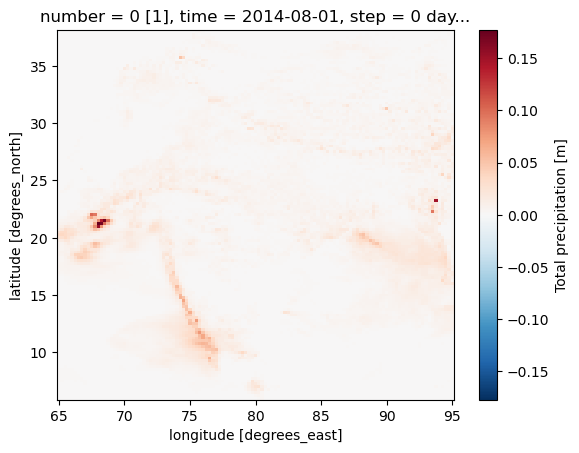

In [56]:
date_str = '2014-08-01'
hres_test.sel(latitude=slice(latmax, latmin), longitude=slice(lonmin, lonmax)).sel(time=date_str).isel(step=2)['tp'].plot()

In [57]:
eval_targets = xr.open_dataset(f'/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/target_init_{date_str} 00:00:00.nc')
eval_targets

/tmp/ipykernel_324926/3321281440.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  eval_targets = xr.open_dataset(f'/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/target_init_{date_str} 00:00:00.nc')


<xarray.Dataset> Size: 606MB
Dimensions:                  (batch: 1, time: 28, lat: 181, lon: 360, level: 13)
Coordinates:
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 104B 50 100 150 200 ... 850 925 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B ...
  * time                     (time) timedelta64[ns] 224B 0 days 06:00:00 ... ...
Dimensions without coordinates: batch
Data variables:
    2m_temperature           (batch, time, lat, lon) float32 7MB ...
    mean_sea_level_pressure  (batch, time, lat, lon) float32 7MB ...
    10m_v_component_of_wind  (batch, time, lat, lon) float32 7MB ...
    10m_u_component_of_wind  (batch, time, lat, lon) float32 7MB ...
    total_precipitation_6hr  (batch, time, lat, lon) float32 7MB ...
    temperature              (batch, time, level, lat, lon) float32 95MB ...
    geopotential             (batch, time, level, lat, lon) float32 95MB ...
    u_component_of_wind      (batch, time, level, lat, lon) float32 95MB ...
    v_component_of_wind      (batch, time, level, lat, lon) float32 95MB ...
    vertical_velocity        (batch, time, level, lat, lon) float32 95MB ...
    specific_humidity        (batch, time, level, lat, lon) float32 95MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-08-06T09:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

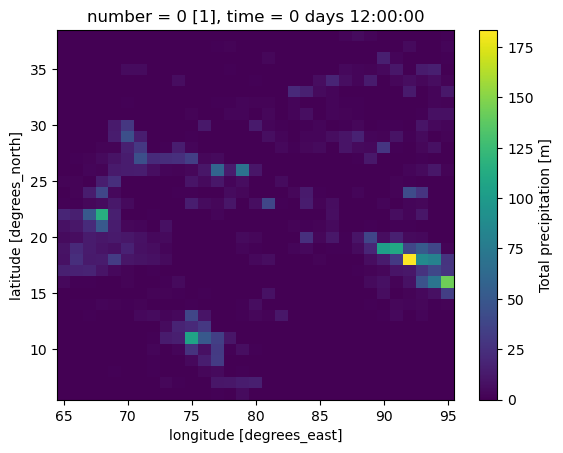

In [58]:
eval_targets['total_precipitation_6hr'].sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).isel(time=1).plot()

In [59]:

def create_regridder(forecast_ds, truth_ds):
    """
    Create xESMF regridder to interpolate forecast data to ground truth grid
    """
    # Create grid datasets for xESMF
    # HRES forecast grid (source - finer resolution)
    forecast_grid = xr.Dataset({
        'lat': (['lat'], forecast_ds.latitude.values),
        'lon': (['lon'], forecast_ds.longitude.values),
    })
    
    # Ground truth grid (target - coarser resolution)
    truth_grid = xr.Dataset({
        'lat': (['lat'], truth_ds.lat.values),
        'lon': (['lon'], truth_ds.lon.values),
    })
    
    # Create regridder (bilinear interpolation)
    regridder = xe.Regridder(
        forecast_grid, 
        truth_grid, 
        'bilinear',
        periodic=True  # Longitude wraps around
    )
    
    return regridder


def regrid_forecast_data(forecast_data, regridder):
    """
    Regrid forecast data using xESMF regridder
    """
    # Rename coordinates to match what xESMF expects
    if 'latitude' in forecast_data.coords:
        forecast_renamed = forecast_data.rename({'latitude': 'lat', 'longitude': 'lon'})
    
    # Apply regridding
    regridded = regridder(forecast_renamed)
    
    return regridded

In [60]:
sample_gt = eval_targets['total_precipitation_6hr'].squeeze('batch')
hres_tp = hres_test['tp']
print("Creating regridder")
regridder = create_regridder(hres_tp.isel(time=0, step=0), sample_gt.isel(time=0))
hres_regrid = hres_test.copy(deep=True)
print("Regridding")
hres_regrid = regrid_forecast_data(hres_regrid, regridder)
hres_regrid

Creating regridder
Regridding


<xarray.Dataset> Size: 1GB
Dimensions:     (time: 92, step: 29, lat: 181, lon: 360)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 736B 2014-06-01 2014-06-02 ... 2014-08-31
  * step        (step) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 21kB ...
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Data variables:
    tp          (time, step, lat, lon) float64 1GB 0.0 0.0 ... 0.002441 0.002441
Attributes:
    regrid_method:  bilinear

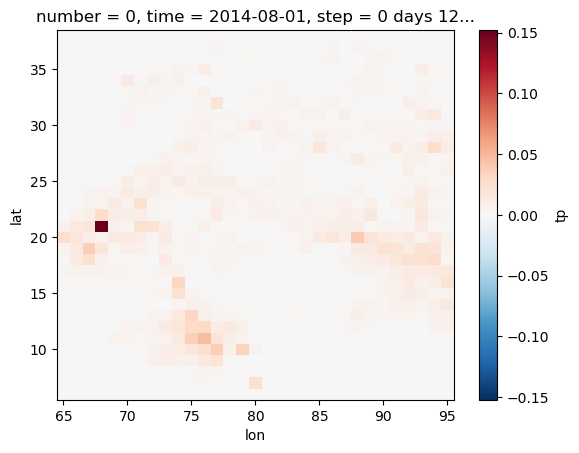

In [61]:
hres_regrid['tp'].sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).sel(time=date_str).isel(step=2).plot()

In [62]:
start_date = '2014-08-01'
hres_aug14  = hres_regrid.sel(time=slice(start_date, None))
hres_aug14

<xarray.Dataset> Size: 469MB
Dimensions:     (time: 31, step: 29, lat: 181, lon: 360)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 248B 2014-08-01 2014-08-02 ... 2014-08-31
  * step        (step) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 7kB ...
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Data variables:
    tp          (time, step, lat, lon) float64 469MB 0.0 0.0 ... 0.002441
Attributes:
    regrid_method:  bilinear

In [63]:
sample_gt

<xarray.DataArray 'total_precipitation_6hr' (time: 28, lat: 181, lon: 360)> Size: 7MB
[1824480 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    number   int64 8B ...
  * time     (time) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
Attributes: (12/32)
    GRIB_NV:                                  0
    GRIB_Nx:                                  360
    GRIB_Ny:                                  181
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           tp
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               m
    GRIB_uvRelativeToGrid:                    0
    long_name:                                Total precipitation
    standard_name:                            unknown
    units:                                    m

In [64]:
hres_regrid_precip = hres_aug14['tp']
hres_regrid_precip

<xarray.DataArray 'tp' (time: 31, step: 29, lat: 181, lon: 360)> Size: 469MB
array([[[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[-1.02338531e-23, -1.02338531e-23, -1.02338531e-23, ...,
          -1.02338531e-23, -1.02338531e-23, -1.02338531e-23],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [-1.02338531e-23, -1.02338531e-23, -1.02338531e-23, ...,
          -1.02338531e-23, -1.02338531e-23, -1.02338531e-23],
...
         [ 2.82287598e-03,  2.86865234e-03,  2.92968750e-03, ...,
           2.73132324e-03,  2.79235840e-03,  2.80761719e-03],
         [ 3.69262695e-03,  3.69262695e-03,  3.69262695e-03, ...,
           3.67736816e-03,  3.67736816e-03,  3.67736816e-03],
         [ 2.34985352e-03,  2.34985352e-03,  2.34985352e-03, ...,
           2.34985352e-03,  2.34985352e-03,  2.34985352e-03]],

        [[ 1.61743164e-03,  1.61743164e-03,  1.61743164e-03, ...,
           1.61743164e-03,  1.61743164e-03,  1.61743164e-03],
         [ 7.01904297e-04,  6.86645508e-04,  6.86645508e-04, ...,
           7.32421875e-04,  7.17163086e-04,  7.01904297e-04],
         [ 4.11987305e-04,  4.11987305e-04,  4.11987305e-04, ...,
           4.42504883e-04,  4.27246094e-04,  4.27246094e-04],
         ...,
         [ 2.88391113e-03,  2.92968750e-03,  2.99072266e-03, ...,
           2.80761719e-03,  2.85339355e-03,  2.86865234e-03],
         [ 3.76892090e-03,  3.76892090e-03,  3.76892090e-03, ...,
           3.73840332e-03,  3.75366211e-03,  3.75366211e-03],
         [ 2.44140625e-03,  2.44140625e-03,  2.44140625e-03, ...,
           2.44140625e-03,  2.44140625e-03,  2.44140625e-03]]]])
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 248B 2014-08-01 2014-08-02 ... 2014-08-31
  * step        (step) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 7kB ...
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0

In [65]:
hres_regrid_precip_date = hres_regrid_precip.sel(time=start_date).isel(step=slice(1, None))
hres_regrid_precip_date

<xarray.DataArray 'tp' (step: 28, lat: 181, lon: 360)> Size: 15MB
array([[[-1.02338531e-23, -1.02338531e-23, -1.02338531e-23, ...,
         -1.02338531e-23, -1.02338531e-23, -1.02338531e-23],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-1.02338531e-23, -1.02338531e-23, -1.02338531e-23, ...,
         -1.02338531e-23, -1.02338531e-23, -1.02338531e-23],
        ...,
        [ 2.09808350e-04,  2.09808350e-04,  2.05993652e-04, ...,
          2.36511230e-04,  2.25067139e-04,  2.17437744e-04],
        [ 4.34875488e-04,  4.31060791e-04,  4.31060791e-04, ...,
          4.31060791e-04,  4.31060791e-04,  4.31060791e-04],
        [ 1.14822388e-03,  1.14822388e-03,  1.14822388e-03, ...,
          1.14822388e-03,  1.14822388e-03,  1.14822388e-03]],

       [[ 7.62939453e-06,  7.62939453e-06,  7.62939453e-06, ...,
          7.62939453e-06,  7.62939453e-06,  7.62939453e-06],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  3.81469727e-06,  3.81469727e-06, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
...
        [ 6.19506836e-03,  6.13403320e-03,  6.07299805e-03, ...,
          6.75964355e-03,  6.57653809e-03,  6.37817383e-03],
        [ 7.67517090e-03,  7.50732422e-03,  7.33947754e-03, ...,
          7.53784180e-03,  7.58361816e-03,  7.62939453e-03],
        [ 9.17053223e-03,  9.17053223e-03,  9.17053223e-03, ...,
          9.17053223e-03,  9.17053223e-03,  9.17053223e-03]],

       [[ 3.50952148e-04,  3.50952148e-04,  3.50952148e-04, ...,
          3.50952148e-04,  3.50952148e-04,  3.50952148e-04],
        [ 1.37329102e-04,  1.52587891e-04,  1.52587891e-04, ...,
          1.37329102e-04,  1.37329102e-04,  1.37329102e-04],
        [ 7.62939453e-05,  7.62939453e-05,  7.62939453e-05, ...,
          9.15527344e-05,  9.15527344e-05,  9.15527344e-05],
        ...,
        [ 6.24084473e-03,  6.17980957e-03,  6.11877441e-03, ...,
          6.82067871e-03,  6.63757324e-03,  6.43920898e-03],
        [ 8.59069824e-03,  8.49914551e-03,  8.39233398e-03, ...,
          8.33129883e-03,  8.42285156e-03,  8.49914551e-03],
        [ 1.37329102e-02,  1.37329102e-02,  1.37329102e-02, ...,
          1.37329102e-02,  1.37329102e-02,  1.37329102e-02]]])
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B 2014-08-01
  * step        (step) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    valid_time  (step) datetime64[ns] 224B ...
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0

In [66]:
if 'time' in sample_gt.dims:
    sample_gt_renamed = sample_gt.rename({'time': 'step'})
sample_gt_renamed

<xarray.DataArray 'total_precipitation_6hr' (step: 28, lat: 181, lon: 360)> Size: 7MB
[1824480 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    number   int64 8B ...
  * step     (step) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
Attributes: (12/32)
    GRIB_NV:                                  0
    GRIB_Nx:                                  360
    GRIB_Ny:                                  181
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           tp
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               m
    GRIB_uvRelativeToGrid:                    0
    long_name:                                Total precipitation
    standard_name:                            unknown
    units:                                    m

In [114]:
diff_step = hres_regrid_precip_date*1000 - sample_gt_renamed
diff_step

<xarray.DataArray (step: 28, lat: 181, lon: 360)> Size: 15MB
array([[[-1.02338531e-20, -1.02338531e-20, -1.02338531e-20, ...,
         -1.02338531e-20, -1.02338531e-20, -1.02338531e-20],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-1.02338531e-20, -1.02338531e-20, -1.02338531e-20, ...,
         -1.02338531e-20, -1.02338531e-20, -1.02338531e-20],
        ...,
        [-1.16519856e+00, -1.16518974e+00, -1.02900779e+00, ...,
         -1.00848997e+00, -1.09743333e+00, -1.09006751e+00],
        [-1.17761993e+00, -1.21143258e+00, -1.22643661e+00, ...,
         -1.35394037e+00, -1.41393995e+00, -1.41893995e+00],
        [-4.79270458e-01, -4.89271522e-01, -5.53439498e-01, ...,
         -6.90942526e-01, -6.78443670e-01, -6.99276924e-01]],

       [[ 7.62939453e-03,  7.62939453e-03,  7.62939453e-03, ...,
          7.62939453e-03,  7.62939453e-03,  7.62939453e-03],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  3.81469727e-03,  3.81469727e-03, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
...
        [ 5.65256274e+00,  5.50153035e+00,  5.44799525e+00, ...,
          6.21963507e+00,  6.03403765e+00,  5.81066698e+00],
        [ 7.25767007e+00,  7.08482096e+00,  7.02446416e+00, ...,
          7.26032755e+00,  7.24860066e+00,  7.22688028e+00],
        [ 8.75053018e+00,  8.78552639e+00,  8.73968372e+00, ...,
          8.84218597e+00,  8.83218357e+00,  8.80176634e+00]],

       [[ 3.50952148e-01,  3.50952148e-01,  3.50952148e-01, ...,
          3.50952148e-01,  3.50952148e-01,  3.50952148e-01],
        [ 1.37329102e-01,  1.52587891e-01,  1.52587891e-01, ...,
          1.37329102e-01,  1.37329102e-01,  1.37329102e-01],
        [ 7.62939453e-02,  7.62939453e-02,  7.62939453e-02, ...,
          9.15527344e-02,  9.15527344e-02,  9.15527344e-02],
        ...,
        [ 3.96335053e+00,  3.99982071e+00,  3.72628355e+00, ...,
          4.85566211e+00,  4.66506493e+00,  4.20670366e+00],
        [ 6.69071186e+00,  6.69915354e+00,  6.59734166e+00, ...,
          6.89880860e+00,  6.86036897e+00,  6.79667139e+00],
        [ 1.18829210e+01,  1.19012532e+01,  1.18820853e+01, ...,
          1.23262527e+01,  1.21670945e+01,  1.21004318e+01]]])
Coordinates:
    number      int64 8B 0
    time        datetime64[ns] 8B 2014-08-01
  * step        (step) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    valid_time  (step) datetime64[ns] 224B ...
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0

In [71]:
hres_regrid_precip_date

<xarray.DataArray 'tp' (step: 28, lat: 181, lon: 360)> Size: 15MB
array([[[-1.02338531e-23, -1.02338531e-23, -1.02338531e-23, ...,
         -1.02338531e-23, -1.02338531e-23, -1.02338531e-23],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-1.02338531e-23, -1.02338531e-23, -1.02338531e-23, ...,
         -1.02338531e-23, -1.02338531e-23, -1.02338531e-23],
        ...,
        [ 2.09808350e-04,  2.09808350e-04,  2.05993652e-04, ...,
          2.36511230e-04,  2.25067139e-04,  2.17437744e-04],
        [ 4.34875488e-04,  4.31060791e-04,  4.31060791e-04, ...,
          4.31060791e-04,  4.31060791e-04,  4.31060791e-04],
        [ 1.14822388e-03,  1.14822388e-03,  1.14822388e-03, ...,
          1.14822388e-03,  1.14822388e-03,  1.14822388e-03]],

       [[ 7.62939453e-06,  7.62939453e-06,  7.62939453e-06, ...,
          7.62939453e-06,  7.62939453e-06,  7.62939453e-06],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  3.81469727e-06,  3.81469727e-06, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
...
        [ 6.19506836e-03,  6.13403320e-03,  6.07299805e-03, ...,
          6.75964355e-03,  6.57653809e-03,  6.37817383e-03],
        [ 7.67517090e-03,  7.50732422e-03,  7.33947754e-03, ...,
          7.53784180e-03,  7.58361816e-03,  7.62939453e-03],
        [ 9.17053223e-03,  9.17053223e-03,  9.17053223e-03, ...,
          9.17053223e-03,  9.17053223e-03,  9.17053223e-03]],

       [[ 3.50952148e-04,  3.50952148e-04,  3.50952148e-04, ...,
          3.50952148e-04,  3.50952148e-04,  3.50952148e-04],
        [ 1.37329102e-04,  1.52587891e-04,  1.52587891e-04, ...,
          1.37329102e-04,  1.37329102e-04,  1.37329102e-04],
        [ 7.62939453e-05,  7.62939453e-05,  7.62939453e-05, ...,
          9.15527344e-05,  9.15527344e-05,  9.15527344e-05],
        ...,
        [ 6.24084473e-03,  6.17980957e-03,  6.11877441e-03, ...,
          6.82067871e-03,  6.63757324e-03,  6.43920898e-03],
        [ 8.59069824e-03,  8.49914551e-03,  8.39233398e-03, ...,
          8.33129883e-03,  8.42285156e-03,  8.49914551e-03],
        [ 1.37329102e-02,  1.37329102e-02,  1.37329102e-02, ...,
          1.37329102e-02,  1.37329102e-02,  1.37329102e-02]]])
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B 2014-08-01
  * step        (step) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    valid_time  (step) datetime64[ns] 224B ...
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0

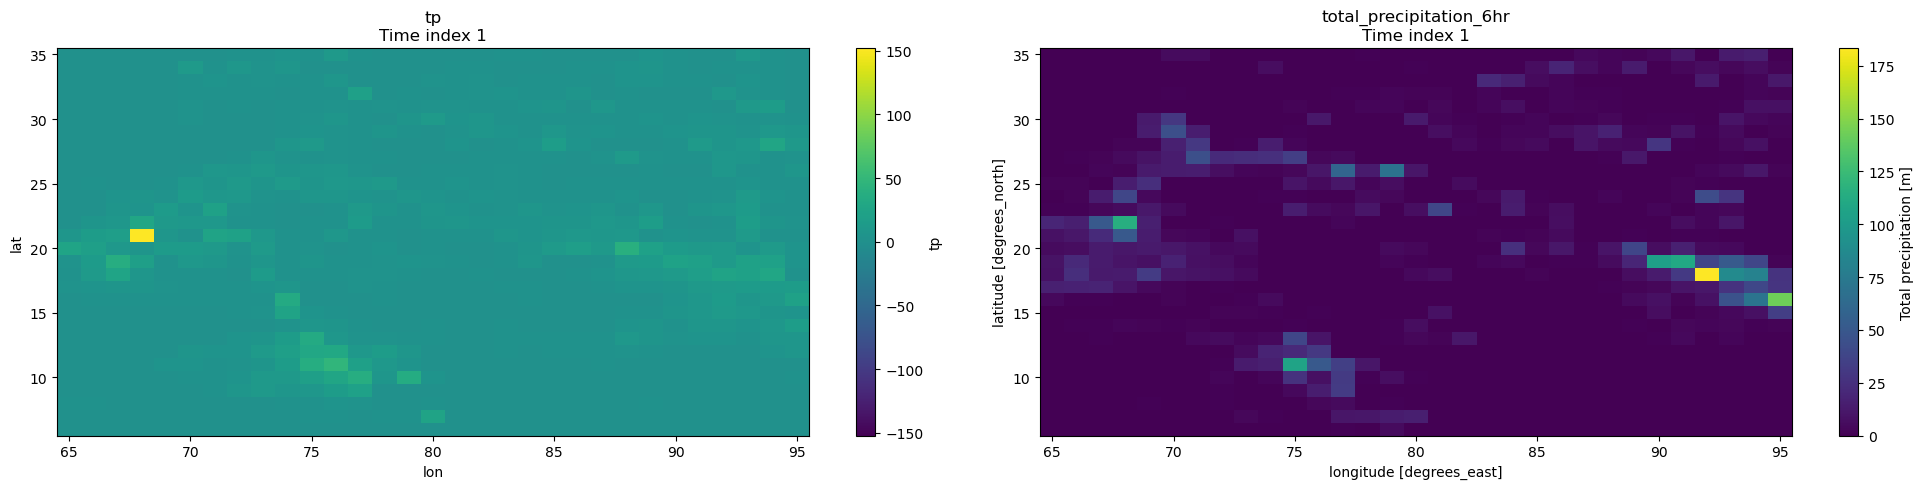

GIF saved to animation.gif


In [86]:
plot_xarrays(hres_regrid_precip_date*1000, sample_gt_renamed, time_index=1, india=True, gif_start=1, gif_end=27, make_gif=True)

In [115]:
diff_step_india = diff_step.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))

In [116]:
dim = ['lat', 'lon']
rmse = np.sqrt((diff_step_india ** 2).mean(dim=dim))
rmse

<xarray.DataArray (step: 28)> Size: 224B
array([11.90840474, 11.77540068, 17.87896483, 19.14744373, 16.59060657,
       17.40628657, 19.81857101, 22.08635708, 22.66260042, 24.86413613,
       26.01673713, 29.91461341, 32.66370515, 35.23896676, 37.62515933,
       41.50905492, 44.30437731, 46.28661722, 47.54230307, 50.48210286,
       53.3539097 , 54.79795383, 56.80192263, 59.70918503, 62.5146824 ,
       65.21171159, 65.65259543, 67.82185336])
Coordinates:
    number      int64 8B 0
    time        datetime64[ns] 8B 2014-08-01
  * step        (step) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    valid_time  (step) datetime64[ns] 224B ...

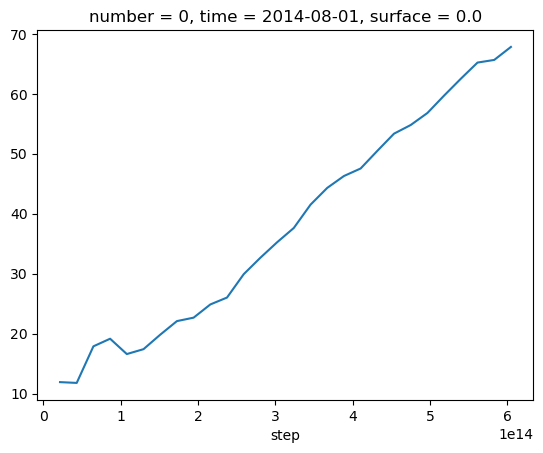

In [117]:
rmse.plot()

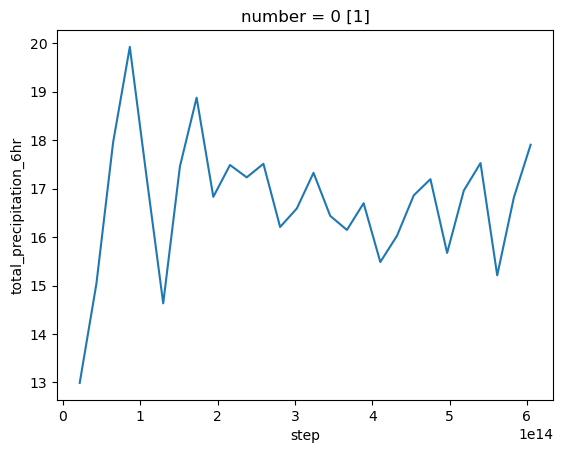

In [120]:
rmse_base.plot()

In [99]:
base_test = xr.open_dataset((f'/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/base_init_{date_str} 00:00:00.nc'))
base_test

/tmp/ipykernel_324926/2567656903.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  base_test = xr.open_dataset((f'/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/base_init_{date_str} 00:00:00.nc'))


<xarray.Dataset> Size: 606MB
Dimensions:                  (time: 28, batch: 1, lat: 181, lon: 360, level: 13)
Coordinates:
  * time                     (time) timedelta64[ns] 224B 0 days 06:00:00 ... ...
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 104B 50 100 150 200 ... 850 925 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B ...
Dimensions without coordinates: batch
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 7MB ...
    10m_v_component_of_wind  (time, batch, lat, lon) float32 7MB ...
    2m_temperature           (time, batch, lat, lon) float32 7MB ...
    geopotential             (time, batch, level, lat, lon) float32 95MB ...
    mean_sea_level_pressure  (time, batch, lat, lon) float32 7MB ...
    specific_humidity        (time, batch, level, lat, lon) float32 95MB ...
    temperature              (time, batch, level, lat, lon) float32 95MB ...
    total_precipitation_6hr  (time, batch, lat, lon) float32 7MB ...
    u_component_of_wind      (time, batch, level, lat, lon) float32 95MB ...
    v_component_of_wind      (time, batch, level, lat, lon) float32 95MB ...
    vertical_velocity        (time, batch, level, lat, lon) float32 95MB ...

In [105]:
base_test_precip = base_test['total_precipitation_6hr'].squeeze('batch')
if 'time' in base_test_precip.dims:
    base_test_precip = base_test_precip.rename({'time': 'step'})
diff_base = base_test_precip - sample_gt_renamed
diff_base

<xarray.DataArray 'total_precipitation_6hr' (step: 28, lat: 181, lon: 360)> Size: 7MB
array([[[ 6.12461445e-05,  6.12461445e-05,  6.03181761e-05, ...,
          6.31020885e-05,  6.17101323e-05,  6.58860081e-05],
        [ 1.07876740e-05,  9.27971905e-06,  1.35715900e-05, ...,
          1.62395081e-05,  1.29336086e-05,  1.38615806e-05],
        [ 9.97569805e-06, -1.50795438e-06,  3.47989470e-07, ...,
          6.61180002e-06,  2.78391576e-06, -6.95978940e-07],
        ...,
        [-2.51593828e-01, -4.14432287e-01, -2.69436002e-01, ...,
          2.15661883e-01,  1.26230717e-03, -1.40636683e-01],
        [-5.69080591e-01, -6.24078155e-01, -7.10359216e-01, ...,
         -6.76232457e-01, -6.91231728e-01, -6.83736324e-01],
        [-5.97529531e-01, -6.64576769e-01, -8.18007052e-01, ...,
         -6.57181263e-01, -6.84683681e-01, -6.88434243e-01]],

       [[ 9.30291862e-05,  9.14052362e-05,  9.14052362e-05, ...,
          9.37251607e-05,  9.21012106e-05,  1.03004888e-04],
        [ 2.57512220e-05,  3.09710631e-05,  2.78391599e-05, ...,
          3.59589103e-05,  2.96371036e-05,  2.82451456e-05],
        [ 2.65631970e-05,  9.27971996e-06,  6.72779652e-06, ...,
          1.35715891e-05,  1.65874990e-05,  1.48475510e-05],
...
         -5.39694846e-01, -5.42177677e-01, -5.67178607e-01],
        [-4.16997194e-01, -4.21992987e-01, -3.14513862e-01, ...,
         -2.77023613e-01, -3.34507674e-01, -4.02011544e-01],
        [-4.19662833e-01, -3.84663314e-01, -4.30507183e-01, ...,
         -3.27986211e-01, -3.37994605e-01, -3.68423849e-01]],

       [[ 1.20752367e-04,  1.26610161e-04,  1.31307985e-04, ...,
          1.32004017e-04,  1.17040458e-04,  1.22260288e-04],
        [ 6.44940592e-05,  6.55380063e-05,  6.13041557e-05, ...,
          4.95304994e-05,  5.38803761e-05,  6.93079055e-05],
        [ 5.10384598e-06, -9.27966539e-07,  4.63982360e-07, ...,
          2.02994033e-06,  8.98972576e-06,  1.20636341e-05],
        ...,
        [-2.27729940e+00, -2.17979407e+00, -2.39228845e+00, ...,
         -1.96483660e+00, -1.97231460e+00, -2.23231339e+00],
        [-1.89962101e+00, -1.79961991e+00, -1.79463112e+00, ...,
         -1.43211842e+00, -1.56212211e+00, -1.70210600e+00],
        [-1.84971309e+00, -1.83137476e+00, -1.85053945e+00, ...,
         -1.40637350e+00, -1.56552660e+00, -1.63219500e+00]]],
      dtype=float32)
Coordinates:
  * step     (step) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    number   int64 8B 0

In [107]:
diff_base_india = diff_base.sel(lat=slice(6, 35), lon=slice(65, 95))

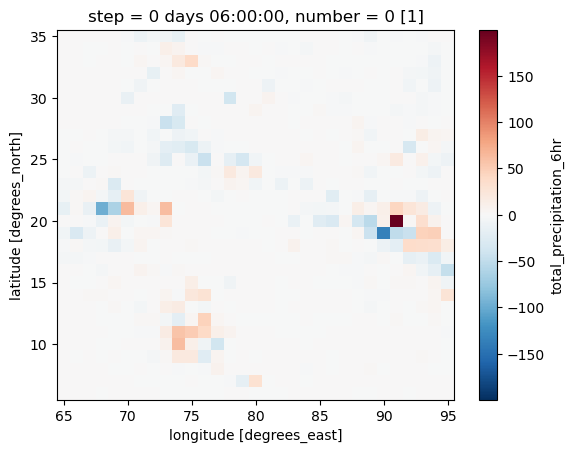

In [118]:
diff_base_india.isel(step=0).plot()

In [119]:
dim = ['lat', 'lon']
rmse_base = np.sqrt((diff_base_india ** 2).mean(dim=dim))
rmse_base

<xarray.DataArray 'total_precipitation_6hr' (step: 28)> Size: 112B
array([12.989812, 15.038624, 17.952816, 19.924284, 17.250412, 14.632445,
       17.456429, 18.877584, 16.830286, 17.487568, 17.232159, 17.511759,
       16.207886, 16.590145, 17.32605 , 16.437748, 16.14682 , 16.698866,
       15.484801, 16.027454, 16.859747, 17.195341, 15.672687, 16.96026 ,
       17.527445, 15.210733, 16.821657, 17.905226], dtype=float32)
Coordinates:
  * step     (step) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
    number   int64 8B 0

In [ ]:
diff_base = base_test['total_precipitation_6hr'].squeeze('batch')

<xarray.DataArray 'total_precipitation_6hr' (time: 28, lat: 181, lon: 360)> Size: 7MB
[1824480 values with dtype=float32]
Coordinates:
  * time     (time) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    number   int64 8B ...

# Looping

In [89]:
def rmse_one_init(hres_regrid_precip, eval_targets, date):
    hres_regrid_precip_date = hres_regrid_precip.sel(time=date).isel(step=slice(1, None))
    sample_targ = eval_targets['total_precipitation_6hr'].squeeze('batch')
    if 'time' in sample_gt.dims:
        sample_gt_renamed = sample_gt.rename({'time': 'step'})
    else:
        sample_gt_renamed = sample_gt

    diff_step = hres_regrid_precip_date*1000 - sample_gt_renamed



<xarray.Dataset> Size: 469MB
Dimensions:     (time: 31, step: 29, lat: 181, lon: 360)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 248B 2014-08-01 2014-08-02 ... 2014-08-31
  * step        (step) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 7kB ...
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Data variables:
    tp          (time, step, lat, lon) float64 469MB 0.0 0.0 ... 0.002441
Attributes:
    regrid_method:  bilinear